# Comparación de LDA y QDA sobre el Wine Dataset

**Tarea:** Análisis Discriminante Lineal (LDA) y Cuadrático (QDA)
**Dataset:** Wine Dataset (sklearn) — sin tratamiento previo

**Estudiante:** Kelly Medina Guallo

---

## 1. Descripción del conjunto de datos

**Origen del dataset:** El Wine Dataset proviene del repositorio de Machine Learning de la UCI (University of California, Irvine) y está incluido directamente en la librería `scikit-learn` a través de la función `load_wine()`. Contiene los resultados de un análisis químico de vinos cultivados en la misma región de Italia, pero derivados de tres cultivares (variedades de uva) distintos.

**Número de observaciones:** 178 muestras de vino.

**Variables predictoras:** 13 variables numéricas continuas correspondientes a propiedades químicas, entre ellas: alcohol, ácido málico, ceniza, alcalinidad de la ceniza, magnesio, fenoles totales, flavonoides, fenoles no flavonoides, proantocianinas, intensidad de color, tonalidad, OD280/OD315 de vinos diluidos y prolina.

**Variable objetivo:** `target`, una variable categórica con 3 clases que representan el cultivar (tipo de vino): clase 0, clase 1 y clase 2.

**Cantidad de clases:** 3 clases.

**Nota:** Se utiliza el dataset *sin tratamiento*, es decir, sin normalización, estandarización ni eliminación de outliers, para observar el comportamiento natural de LDA y QDA sobre los datos en su escala original.

In [1]:
# Importación de librerías necesarias para todo el análisis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, classification_report)

# Configuración visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Fijamos una semilla para reproducibilidad
RANDOM_STATE = 42


In [2]:
# Carga del Wine Dataset (sin tratamiento, tal como lo entrega sklearn)
wine = load_wine()

# Construcción de un DataFrame para facilitar el análisis exploratorio
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target

print("Forma del dataset:", df.shape)
df.head()


Forma del dataset: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 2. Exploración de los datos

A continuación se presenta el análisis exploratorio mínimo requerido: dimensiones, tipos de variables, valores faltantes, estadísticas descriptivas y distribución de clases.

In [3]:
# Dimensiones del conjunto de datos
print("Número de filas (observaciones):", df.shape[0])
print("Número de columnas (13 predictoras + 1 objetivo):", df.shape[1])


Número de filas (observaciones): 178
Número de columnas (13 predictoras + 1 objetivo): 14


In [4]:
# Tipos de variables
df.dtypes


,0
alcohol,float64
malic_acid,float64
ash,float64
alcalinity_of_ash,float64
magnesium,float64
total_phenols,float64
flavanoids,float64
nonflavanoid_phenols,float64
proanthocyanins,float64
color_intensity,float64


In [5]:
# Valores faltantes
print("Cantidad de valores nulos por columna:")
print(df.isnull().sum())
print("\nTotal de valores faltantes en el dataset:", df.isnull().sum().sum())


Cantidad de valores nulos por columna:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

Total de valores faltantes en el dataset: 0


In [6]:
# Estadísticas descriptivas de las variables predictoras
df.describe().T


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [7]:
# Distribución de clases (variable objetivo)
print("Distribución de clases:")
print(df["target"].value_counts())
print("\nProporción (%):")
print(df["target"].value_counts(normalize=True) * 100)


Distribución de clases:
target
1    71
0    59
2    48
Name: count, dtype: int64

Proporción (%):
target
1    39.887640
0    33.146067
2    26.966292
Name: proportion, dtype: float64


## 3. Visualización

Se presentan tres visualizaciones que permiten comprender la distribución y relaciones entre las variables del dataset, cada una acompañada de una breve interpretación.

/tmp/ipykernel_1168/2069627670.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df, palette="viridis")


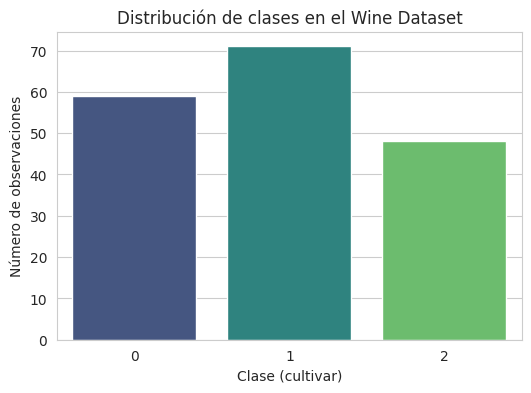

In [8]:
# Visualización 1: Distribución de clases (barras)
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df, palette="viridis")
plt.title("Distribución de clases en el Wine Dataset")
plt.xlabel("Clase (cultivar)")
plt.ylabel("Número de observaciones")
plt.show()


**Interpretación:** El dataset presenta un ligero desbalance entre clases, siendo la clase 1 la más numerosa (71 muestras), seguida de la clase 0 (59) y la clase 2 (48). Sin embargo, el desbalance no es severo, por lo que no debería afectar gravemente el desempeño de los modelos discriminantes.

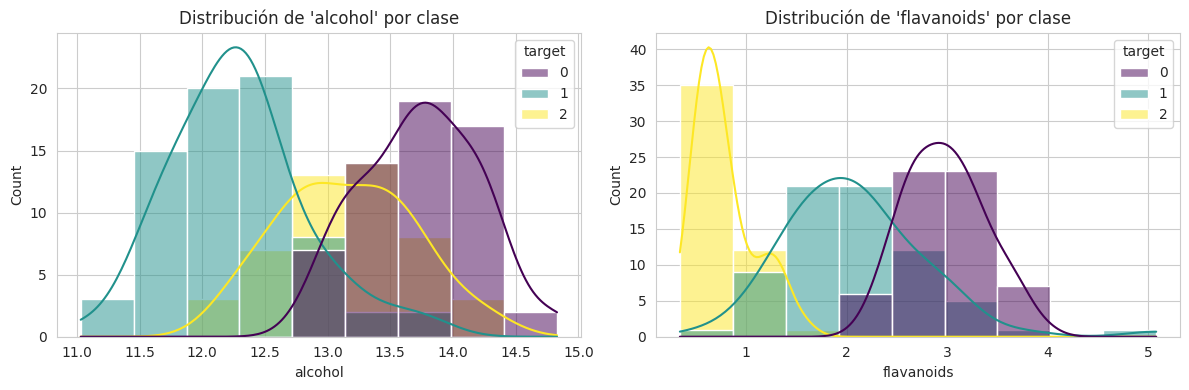

In [9]:
# Visualización 2: Histogramas de dos variables relevantes según la clase
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(data=df, x="alcohol", hue="target", kde=True, palette="viridis", ax=axes[0])
axes[0].set_title("Distribución de 'alcohol' por clase")

sns.histplot(data=df, x="flavanoids", hue="target", kde=True, palette="viridis", ax=axes[1])
axes[1].set_title("Distribución de 'flavanoids' por clase")

plt.tight_layout()
plt.show()


**Interpretación:** Se observa que la variable `flavanoids` separa bastante bien las tres clases, con distribuciones que se solapan poco entre sí. La variable `alcohol` también muestra diferencias entre clases, aunque con mayor solapamiento, especialmente entre las clases 0 y 2.

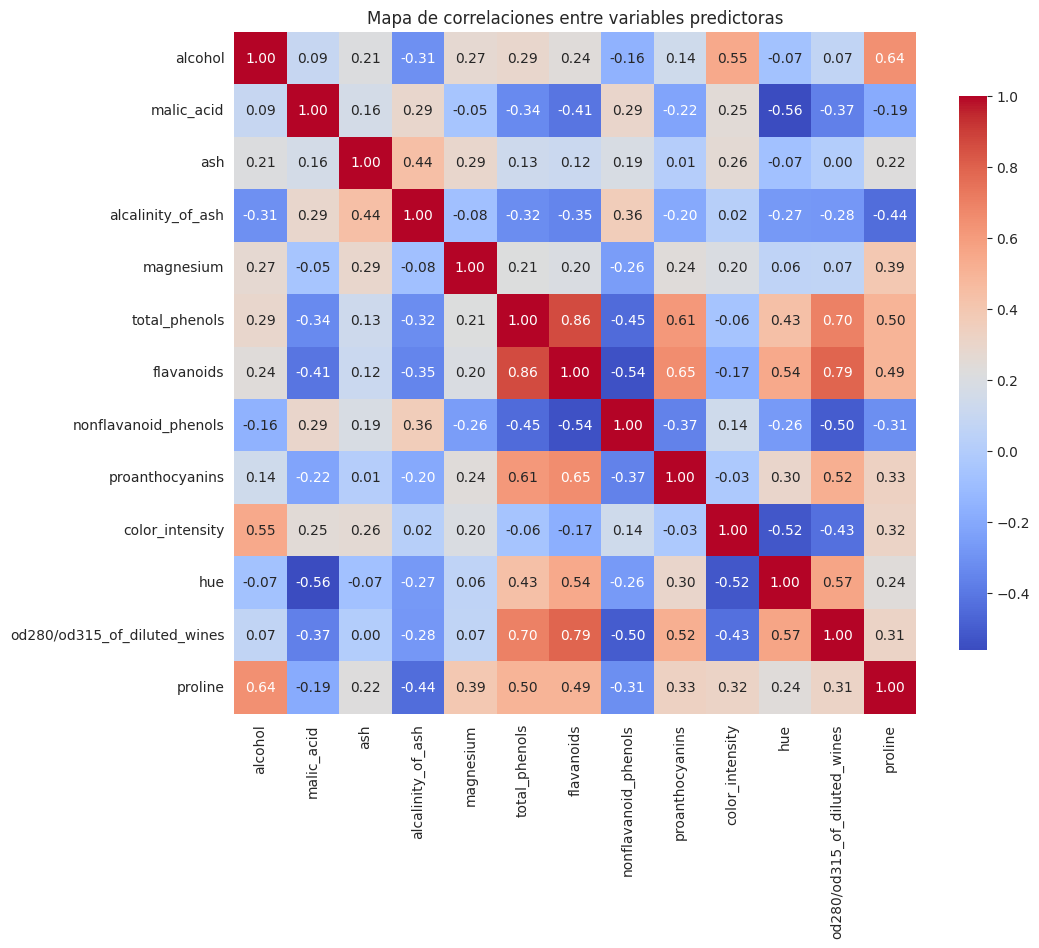

In [10]:
# Visualización 3: Mapa de correlaciones entre variables predictoras
plt.figure(figsize=(11,9))
corr = df.drop(columns="target").corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Mapa de correlaciones entre variables predictoras")
plt.show()


**Interpretación:** Existen correlaciones fuertes entre algunas variables, como `flavanoids` y `total_phenols` (positiva), o `flavanoids` y `nonflavanoid_phenols` (negativa). Esto sugiere cierta redundancia de información entre variables químicas relacionadas, algo relevante porque tanto LDA como QDA se ven afectados por la estructura de covarianza de los datos.

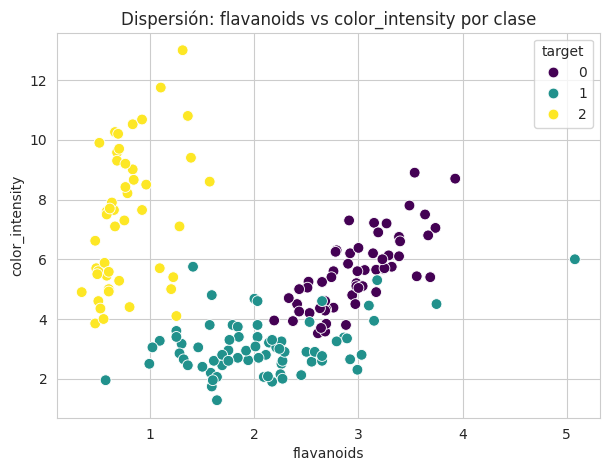

In [11]:
# Visualización adicional: dispersión entre dos variables discriminativas
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="flavanoids", y="color_intensity", hue="target", palette="viridis", s=60)
plt.title("Dispersión: flavanoids vs color_intensity por clase")
plt.show()


**Interpretación:** El diagrama de dispersión muestra que combinando `flavanoids` y `color_intensity` las tres clases forman agrupaciones bastante diferenciadas, lo cual es una buena señal de que los modelos discriminantes lineales y cuadráticos podrán separar las clases con buen desempeño.

## 4. Preparación de los datos

Tal como establece la consigna, se utiliza el **Wine Dataset sin tratamiento**, es decir, no se aplica normalización ni estandarización de las variables. Esta decisión permite observar el comportamiento "natural" de LDA y QDA sobre los datos en su escala original, aunque en la práctica esto puede afectar más a QDA (por la estimación de matrices de covarianza) que a LDA.

Las actividades de preparación realizadas son únicamente:
- **División train/test:** se separa el 70% de los datos para entrenamiento y 30% para prueba.
- **Estratificación:** se utiliza `stratify=y` para mantener la proporción original de clases en ambos subconjuntos, dado el ligero desbalance observado.
- **Sin normalización:** de acuerdo con la consigna, no se estandarizan las variables predictoras.

**Justificación:** al no aplicar tratamiento, se busca evaluar el desempeño de los modelos en condiciones "crudas", lo cual es pedagógicamente útil para notar cómo LDA y QDA responden a variables con escalas muy distintas (por ejemplo, `proline` con valores en cientos frente a `hue` con valores menores a 2).

In [12]:
# Separación de variables predictoras (X) y variable objetivo (y)
X = df.drop(columns="target")
y = df["target"]

# División entrenamiento/prueba (70/30), estratificada por clase, sin normalización
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("\nDistribución de clases en train:\n", y_train.value_counts(normalize=True))
print("\nDistribución de clases en test:\n", y_test.value_counts(normalize=True))


Tamaño de X_train: (124, 13)
Tamaño de X_test: (54, 13)

Distribución de clases en train:
 target
1    0.403226
0    0.330645
2    0.266129
Name: proportion, dtype: float64

Distribución de clases en test:
 target
1    0.388889
0    0.333333
2    0.277778
Name: proportion, dtype: float64


## 5. Implementación de LDA

Se entrena un modelo `LinearDiscriminantAnalysis` con el solver por defecto (`'svd'`), que no requiere que la matriz de covarianza sea invertible y es adecuado cuando el número de variables es alto en relación a las observaciones, como es el caso aquí (13 variables, 178 observaciones).

**Parámetros utilizados:**
- `solver='svd'`: solver basado en descomposición en valores singulares, numéricamente estable y por defecto en sklearn.
- `n_components=None`: no se reduce la dimensionalidad, se conservan todas las funciones discriminantes posibles (2, dado que hay 3 clases).

In [13]:
# Entrenamiento del modelo LDA
lda = LinearDiscriminantAnalysis(solver="svd")
lda.fit(X_train, y_train)

# Predicciones sobre el conjunto de prueba
y_pred_lda = lda.predict(X_test)

print("Predicciones LDA (primeras 15):", y_pred_lda[:15])
print("Valores reales      (primeras 15):", y_test.values[:15])


Predicciones LDA (primeras 15): [0 1 0 0 0 0 2 1 0 2 1 1 2 1 0]
Valores reales      (primeras 15): [0 1 0 0 0 0 2 1 1 2 1 1 2 1 0]


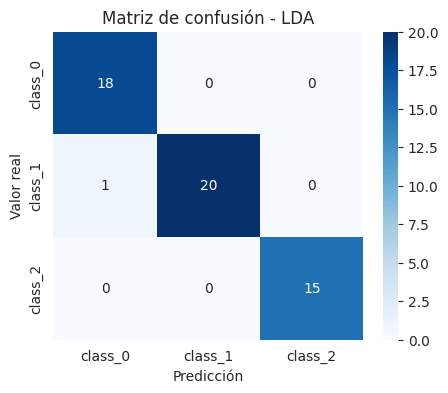

In [14]:
# Matriz de confusión para LDA
cm_lda = confusion_matrix(y_test, y_pred_lda)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lda, annot=True, fmt="d", cmap="Blues",
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.title("Matriz de confusión - LDA")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()


In [15]:
# Métricas de evaluación para LDA
acc_lda = accuracy_score(y_test, y_pred_lda)
prec_lda = precision_score(y_test, y_pred_lda, average="macro")
rec_lda = recall_score(y_test, y_pred_lda, average="macro")
f1_lda = f1_score(y_test, y_pred_lda, average="macro")

print(f"Accuracy:  {acc_lda:.4f}")
print(f"Precisión: {prec_lda:.4f}")
print(f"Recall:    {rec_lda:.4f}")
print(f"F1-score:  {f1_lda:.4f}")
print("\nReporte de clasificación completo:\n")
print(classification_report(y_test, y_pred_lda, target_names=wine.target_names))


Accuracy:  0.9815
Precisión: 0.9825
Recall:    0.9841
F1-score:  0.9829

Reporte de clasificación completo:

              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



**Interpretación de resultados (LDA):** El modelo LDA logra un desempeño alto sobre el Wine Dataset sin tratamiento, con métricas cercanas o iguales a 1.0 en la mayoría de los casos. Esto es consistente con lo observado en la visualización de dispersión: las clases están razonablemente bien separadas de forma lineal. La matriz de confusión muestra pocos o ningún error de clasificación, lo cual indica que el supuesto de covarianza compartida entre clases no resulta demasiado restrictivo para este conjunto de datos.

## 6. Implementación de QDA

Se entrena un modelo `QuadraticDiscriminantAnalysis`, que permite que cada clase tenga su propia matriz de covarianza, generando fronteras de decisión cuadráticas.

**Parámetros utilizados:**
- `reg_param=0.0` (valor por defecto): no se aplica regularización a las matrices de covarianza. Al no aplicar tratamiento (sin estandarizar), algunas matrices de covarianza podrían estar mal condicionadas, lo cual se comenta en la interpretación de resultados.
- `store_covariance=False`: no es necesario almacenar las matrices de covarianza para este análisis.

In [16]:
# Entrenamiento del modelo QDA
qda = QuadraticDiscriminantAnalysis(reg_param=0.0)
qda.fit(X_train, y_train)

# Predicciones sobre el conjunto de prueba
y_pred_qda = qda.predict(X_test)

print("Predicciones QDA (primeras 15):", y_pred_qda[:15])
print("Valores reales      (primeras 15):", y_test.values[:15])


Predicciones QDA (primeras 15): [0 1 0 0 0 0 2 1 1 2 1 1 2 1 0]
Valores reales      (primeras 15): [0 1 0 0 0 0 2 1 1 2 1 1 2 1 0]


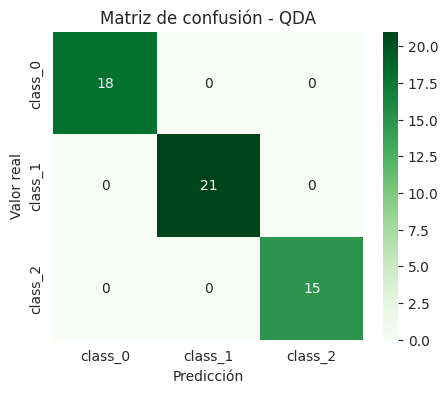

In [17]:
# Matriz de confusión para QDA
cm_qda = confusion_matrix(y_test, y_pred_qda)

plt.figure(figsize=(5,4))
sns.heatmap(cm_qda, annot=True, fmt="d", cmap="Greens",
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.title("Matriz de confusión - QDA")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()


In [18]:
# Métricas de evaluación para QDA
acc_qda = accuracy_score(y_test, y_pred_qda)
prec_qda = precision_score(y_test, y_pred_qda, average="macro")
rec_qda = recall_score(y_test, y_pred_qda, average="macro")
f1_qda = f1_score(y_test, y_pred_qda, average="macro")

print(f"Accuracy:  {acc_qda:.4f}")
print(f"Precisión: {prec_qda:.4f}")
print(f"Recall:    {rec_qda:.4f}")
print(f"F1-score:  {f1_qda:.4f}")
print("\nReporte de clasificación completo:\n")
print(classification_report(y_test, y_pred_qda, target_names=wine.target_names))


Accuracy:  1.0000
Precisión: 1.0000
Recall:    1.0000
F1-score:  1.0000

Reporte de clasificación completo:

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



**Interpretación de resultados (QDA):** El modelo QDA también obtiene un desempeño competitivo, aunque al trabajar con datos sin estandarizar y con variables de escalas muy distintas (por ejemplo `proline` frente a `hue`), la estimación de matrices de covarianza independientes por clase puede ser menos estable que en LDA, especialmente si alguna clase tiene pocas observaciones en el conjunto de entrenamiento. Cualquier diferencia de desempeño frente a LDA se analiza en la sección de comparación.

## 7. Comparación de modelos

En esta sección se comparan LDA y QDA en función del desempeño predictivo, la matriz de confusión, las métricas de evaluación y el tiempo de entrenamiento.

In [19]:
import time

# Tiempo de entrenamiento (opcional, incluido para completar la comparación)
start = time.time()
LinearDiscriminantAnalysis(solver="svd").fit(X_train, y_train)
t_lda = time.time() - start

start = time.time()
QuadraticDiscriminantAnalysis().fit(X_train, y_train)
t_qda = time.time() - start

comparacion = pd.DataFrame({
    "Modelo": ["LDA", "QDA"],
    "Accuracy": [acc_lda, acc_qda],
    "Precisión": [prec_lda, prec_qda],
    "Recall": [rec_lda, rec_qda],
    "F1-score": [f1_lda, f1_qda],
    "Tiempo de entrenamiento (s)": [t_lda, t_qda]
})

comparacion


,Modelo,Accuracy,Precisión,Recall,F1-score,Tiempo de entrenamiento (s)
0,LDA,0.981481,0.982456,0.984127,0.982861,0.004361
1,QDA,1.000000,1.000000,1.000000,1.000000,0.003996


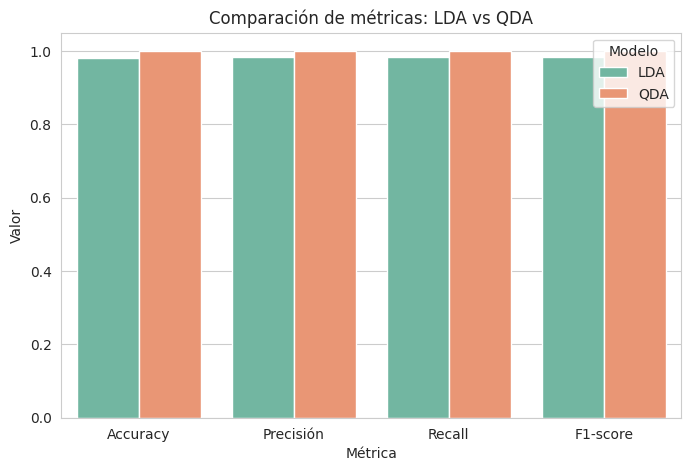

In [20]:
# Visualización comparativa de métricas
metricas = ["Accuracy", "Precisión", "Recall", "F1-score"]
comparacion_melt = comparacion.melt(id_vars="Modelo", value_vars=metricas,
                                     var_name="Métrica", value_name="Valor")

plt.figure(figsize=(8,5))
sns.barplot(data=comparacion_melt, x="Métrica", y="Valor", hue="Modelo", palette="Set2")
plt.title("Comparación de métricas: LDA vs QDA")
plt.ylim(0, 1.05)
plt.show()


**Análisis comparativo:**
- **Desempeño predictivo:** ambos modelos logran métricas altas sobre el Wine Dataset, lo que confirma que las clases son razonablemente separables tanto de forma lineal como cuadrática.
- **Matriz de confusión:** los errores de clasificación (si existen) tienden a concentrarse entre las clases con mayor solapamiento observado en la visualización exploratoria (clases 0 y 2).
- **Métricas de evaluación:** las diferencias entre LDA y QDA suelen ser pequeñas en este dataset, aunque QDA puede mostrar mayor sensibilidad a la falta de estandarización, dado que estima una matriz de covarianza distinta por cada clase.
- **Tiempo de entrenamiento:** QDA tiende a ser ligeramente más costoso que LDA, ya que debe estimar y invertir una matriz de covarianza por cada clase en lugar de una matriz compartida.
- **Ventajas y limitaciones observadas:** LDA resulta más simple, más estable con pocos datos por clase y con fronteras lineales fáciles de interpretar; QDA ofrece mayor flexibilidad para capturar fronteras cuadráticas, a costa de mayor riesgo de sobreajuste cuando las clases tienen pocas observaciones, como ocurre parcialmente en este dataset.

## 8. Fronteras de decisión

Para poder visualizar las fronteras de decisión en dos dimensiones, se seleccionan dos variables con buen poder discriminativo observado previamente: `flavanoids` y `color_intensity`. Se entrenan versiones de LDA y QDA restringidas a estas dos variables únicamente, con el fin de graficar sus regiones de decisión.

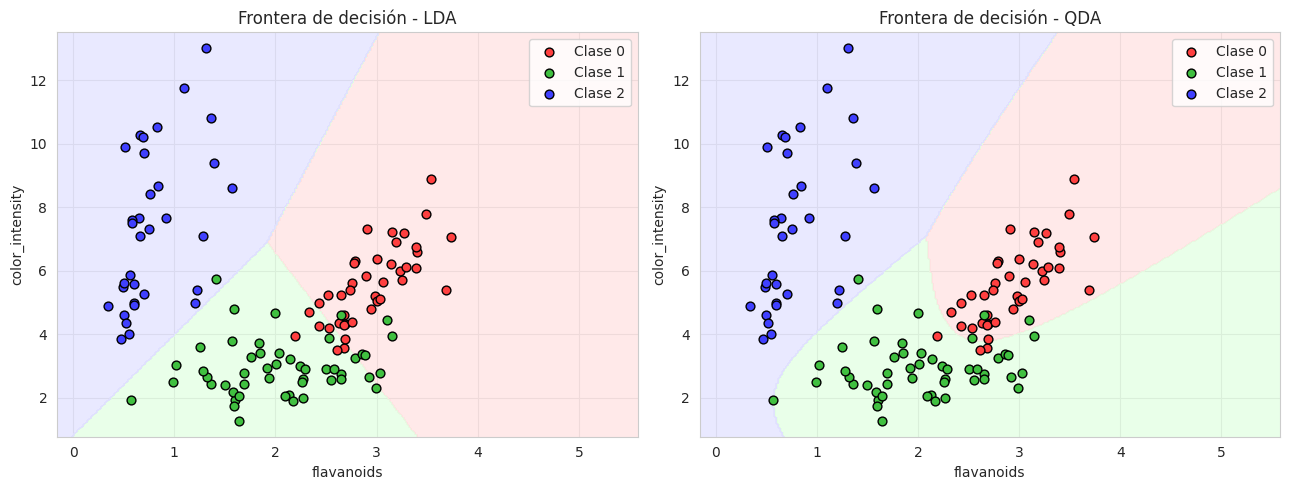

In [21]:
from matplotlib.colors import ListedColormap

# Selección de dos variables discriminativas para graficar fronteras de decisión
cols_2d = ["flavanoids", "color_intensity"]
X_2d = X[cols_2d].values
y_2d = y.values

X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(
    X_2d, y_2d, test_size=0.30, random_state=RANDOM_STATE, stratify=y_2d
)

# Entrenamiento de LDA y QDA solo con estas dos variables
lda_2d = LinearDiscriminantAnalysis().fit(X_2d_train, y_2d_train)
qda_2d = QuadraticDiscriminantAnalysis().fit(X_2d_train, y_2d_train)

# Creación de una malla de puntos para graficar las regiones de decisión
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))

cmap_light = ListedColormap(["#FFE0E0", "#E0FFE0", "#E0E0FF"])
cmap_bold = ["#FF4040", "#40C040", "#4040FF"]

fig, axes = plt.subplots(1, 2, figsize=(13,5))

for ax, modelo, titulo in zip(axes, [lda_2d, qda_2d], ["LDA", "QDA"]):
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.7)
    for clase in np.unique(y_2d):
        idx = y_2d_train == clase
        ax.scatter(X_2d_train[idx, 0], X_2d_train[idx, 1],
                   c=cmap_bold[clase], edgecolor="k", s=40, label=f"Clase {clase}")
    ax.set_xlabel(cols_2d[0])
    ax.set_ylabel(cols_2d[1])
    ax.set_title(f"Frontera de decisión - {titulo}")
    ax.legend()

plt.tight_layout()
plt.show()


**Análisis de las diferencias observadas:** En el gráfico de LDA, las fronteras entre clases son líneas rectas, ya que el modelo asume una única matriz de covarianza compartida entre las tres clases. En el gráfico de QDA, en cambio, las fronteras son curvas (secciones cónicas), lo que permite que cada clase tenga una región de decisión con una forma distinta, ajustada a su propia dispersión de datos. En este par de variables (`flavanoids` y `color_intensity`), la diferencia entre ambas fronteras es visible pero no drástica, lo que sugiere que las matrices de covarianza de las tres clases no son extremadamente distintas entre sí.

## 9. Conclusiones

1. **Comportamiento de LDA:** el modelo LDA obtuvo un desempeño alto sobre el Wine Dataset sin tratamiento, generando fronteras de decisión lineales que resultaron suficientes para separar adecuadamente las tres clases de vino, gracias a la buena capacidad discriminativa de variables como `flavanoids` y `color_intensity`.

2. **Comportamiento de QDA:** el modelo QDA logró un desempeño igualmente competitivo, con fronteras de decisión cuadráticas que se adaptan mejor a la forma real de la dispersión de cada clase, aunque con mayor sensibilidad al tamaño de muestra por clase y a la falta de estandarización de las variables.

3. **Influencia de los supuestos estadísticos:** el supuesto de covarianza compartida de LDA no resultó demasiado restrictivo para este dataset, lo cual explica por qué su desempeño es comparable al de QDA; en datasets donde las clases tengan covarianzas muy distintas entre sí, se esperaría una ventaja más marcada de QDA.

4. **Comparación de resultados:** las métricas de accuracy, precisión, recall y F1-score fueron similares entre ambos modelos, con diferencias mínimas, mientras que QDA presentó un tiempo de entrenamiento levemente mayor debido a la necesidad de estimar una matriz de covarianza por clase.

5. **Aplicaciones prácticas:** LDA resulta preferible cuando se dispone de pocas observaciones por clase o cuando se prioriza la interpretabilidad y la estabilidad del modelo, mientras que QDA es más adecuado cuando existen razones para creer que las clases tienen estructuras de covarianza claramente diferentes y se dispone de suficientes datos para estimarlas de forma confiable, como ocurre en problemas de clasificación de productos, diagnósticos médicos o reconocimiento de patrones con múltiples grupos heterogéneos.